## Bag of Words

## Binary Based Bag Of Words

In [1]:
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
corpus=[" i love nlp" ,"nlp is a branch of artificial intelligence","nlp that enables computers to understand","I enjoy Learning nlp"]

In [3]:
vect=CountVectorizer(binary=True) # Binary triue means binar ba of words

In [4]:
bag=vect.fit_transform(corpus)

In [5]:
print("Vocabulary:",vect.get_feature_names_out())
print("Bow Matrix:\n",bag.toarray())

Vocabulary: ['artificial' 'branch' 'computers' 'enables' 'enjoy' 'intelligence' 'is'
 'learning' 'love' 'nlp' 'of' 'that' 'to' 'understand']
Bow Matrix:
 [[0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [1 1 0 0 0 1 1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0 0 1 0 1 1 1]
 [0 0 0 0 1 0 0 1 0 1 0 0 0 0]]


## Count Based Bag Of Words

In [13]:
cor=[" i love nlp and nlp is part of data science" ,"nlp is a branch of artificial intelligence","nlp that enables computers to understand","I enjoy Learning nlp"]

In [14]:
vect=CountVectorizer(binary=False) # Binary false means count based bag of words

In [15]:
bag=vect.fit_transform(cor)

In [16]:
print("Vocabulary:",vect.get_feature_names_out())
print("Bow Matrix:\n",bag.toarray())

Vocabulary: ['and' 'artificial' 'branch' 'computers' 'data' 'enables' 'enjoy'
 'intelligence' 'is' 'learning' 'love' 'nlp' 'of' 'part' 'science' 'that'
 'to' 'understand']
Bow Matrix:
 [[1 0 0 0 1 0 0 0 1 0 1 2 1 1 1 0 0 0]
 [0 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0]]


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("amazon_reviews.csv")

df.head(5)

,sentiments,cleaned_review,review_score
0,positive,i wish would have gotten one earlier love it a...,5
1,neutral,i ve learned this lesson again open the packag...,1
2,neutral,it is so slow and lags find better option,2
3,neutral,roller ball stopped working within months of m...,1
4,neutral,i like the color and size but it few days out ...,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sentiments      17340 non-null  object
 1   cleaned_review  17337 non-null  object
 2   review_score    17340 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 406.5+ KB


In [21]:
df.isnull().sum()

sentiments        0
cleaned_review    3
review_score      0
dtype: int64

In [23]:
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17337 entries, 0 to 17339
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sentiments      17337 non-null  object
 1   cleaned_review  17337 non-null  object
 2   review_score    17337 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 541.8+ KB


In [25]:
df.duplicated().sum()

np.int64(1347)

In [26]:
df=df.drop_duplicates()

In [28]:
df.shape

(15990, 3)

In [30]:
from sklearn.feature_extraction.text import CountVectorizer
vect=CountVectorizer(binary=True) 
bag=vect.fit_transform(df['cleaned_review'])
print("Vocabulary:",vect.get_feature_names_out())
print("Bow Matrix:\n",bag.toarray())

Vocabulary: ['aa' 'aaa' 'aaaaa' ... 'zooming' 'zooms' 'zumba']
Bow Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## count Based

In [32]:
vect=CountVectorizer(binary=False) 
bag=vect.fit_transform(df['cleaned_review'])
print("Vocabulary:",vect.get_feature_names_out())
print("Bow Matrix:\n",bag.toarray())

Vocabulary: ['aa' 'aaa' 'aaaaa' ... 'zooming' 'zooms' 'zumba']
Bow Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [34]:
df["review_length"]=df["cleaned_review"].apply(len)

In [35]:
df.head()

,sentiments,cleaned_review,review_score,review_length
0,positive,i wish would have gotten one earlier love it a...,5,93
1,neutral,i ve learned this lesson again open the packag...,1,460
2,neutral,it is so slow and lags find better option,2,41
3,neutral,roller ball stopped working within months of m...,1,71
4,neutral,i like the color and size but it few days out ...,1,94


# word frequency analysis

In [36]:
from collections import Counter
import re

# Function to clean text and extract words
def get_words(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    words = text.split()
    return words

# Get all words from the dataset
all_words = df["cleaned_review"].apply(get_words).sum()

# Count word frequencies
word_counts = Counter(all_words)

# Display the most common words
print(word_counts.most_common(10))

[('the', 25196), ('it', 21988), ('and', 16675), ('to', 12547), ('for', 9503), ('is', 9264), ('this', 8208), ('my', 6368), ('mouse', 5828), ('of', 5307)]


In [40]:
n=10
print(word_counts.most_common(n))

[('the', 25196), ('it', 21988), ('and', 16675), ('to', 12547), ('for', 9503), ('is', 9264), ('this', 8208), ('my', 6368), ('mouse', 5828), ('of', 5307)]


In [43]:
!pip install wordcloud

## Word Cloud Visuvalization

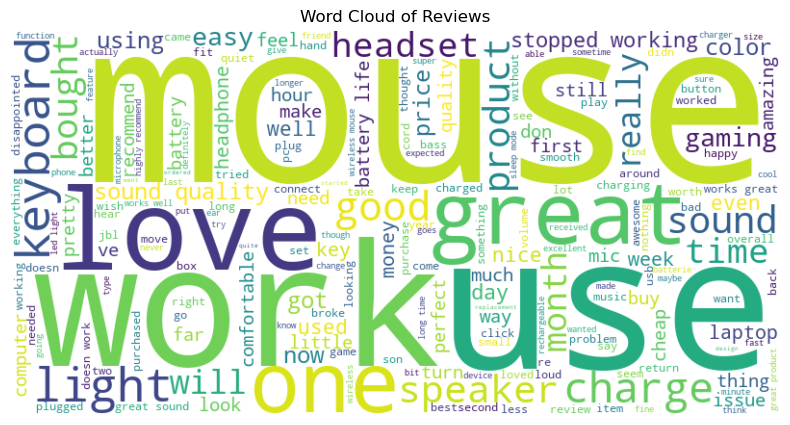

In [44]:
from wordcloud import WordCloud

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(all_words))

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()